# Mask Detection - Data Analysis & Experiment Orchestration

This notebook handles data analysis and orchestrates model training experiments.

## Dataset Setup

We use the following Kaggle datasets for mask detection:

1. **Face Mask 12K Images Dataset** - https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset

In [19]:
#!/bin/bash
!kaggle datasets download ashishjangra27/face-mask-12k-images-dataset

/Users/tanliangwei/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Dataset URL: https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset
License(s): CC0-1.0
 70%|███████████████████████████▉            | 231M/330M [00:00<00:00, 1.25GB/s]
100%|████████████████████████████████████████| 330M/330M [00:00<00:00, 1.26GB/s]


In [ ]:
!unzip face-mask-12k-images-dataset.zip -d face-mask-12k-images-dataset/

## Import required packages

In [1]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

I0000 00:00:1776087712.561603    3253 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776087712.594208    3253 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776087713.522402    3253 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load and observe data

In [2]:
#Load train and test set
test_data_root_dir = 'face-mask-12k-images-dataset/Face Mask Dataset/'
train_dir = test_data_root_dir + 'Train'
test_dir  = test_data_root_dir + 'Test'
val_dir   = test_data_root_dir + 'Validation'

In [3]:
batch_size = 32
img_height = 128
img_width = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 10000 files belonging to 2 classes.


W0000 00:00:1776087766.623096    3253 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776087766.640691    3253 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776087766.747987    3253 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94891 MB memory:  -> device: 0, name: NVIDIA RTX PRO 6000 Blackwell Server Edition, pci bus id: 0000:76:00.0, compute capability: 12.0a


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  val_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


In [5]:
class_names = train_ds.class_names
print(class_names)

['WithMask', 'WithoutMask']


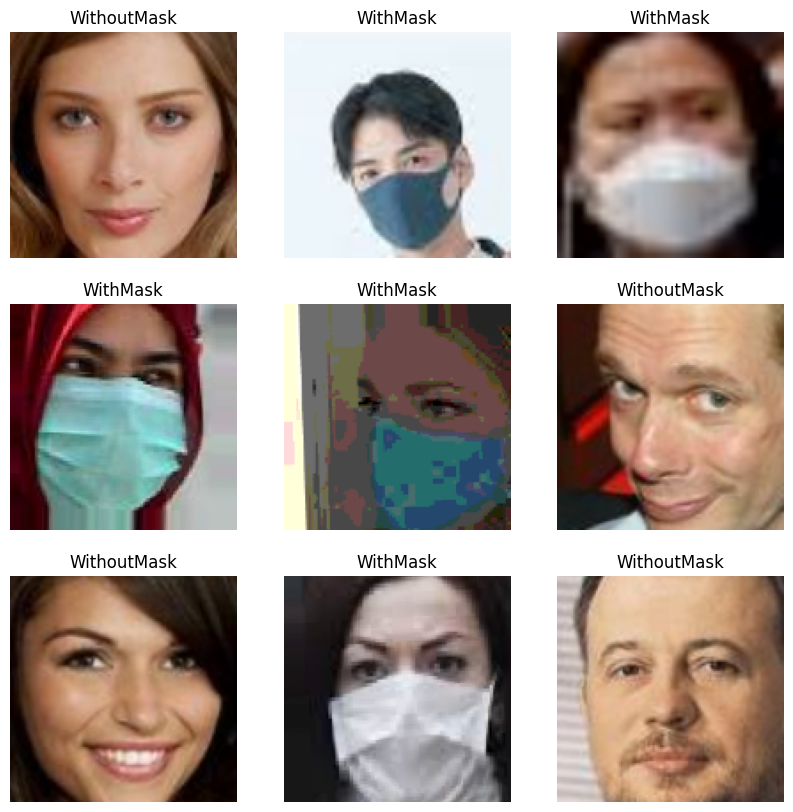

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [7]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 128, 128, 3)
(32,)


## Build Models

### Baseline model
```
model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes)
])
```

In [13]:
!python -m train baseline_cnn 

I0000 00:00:1776088098.196685   44017 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776088098.226581   44017 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776088099.213828   44017 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Loading model: baseline_cnn
Loading datasets...
Found 10000 files belonging to 2 classes.
W0000 00:00:

Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


Finding latest checkpoint...
Loading model from: checkpoints/baseline_cnn/model-20-0.0096.h5

Evaluating model...
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9909 - loss: 0.0348       
Test Loss: 0.0348
Test Accuracy: 0.9909
['WithMask', 'WithoutMask']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step


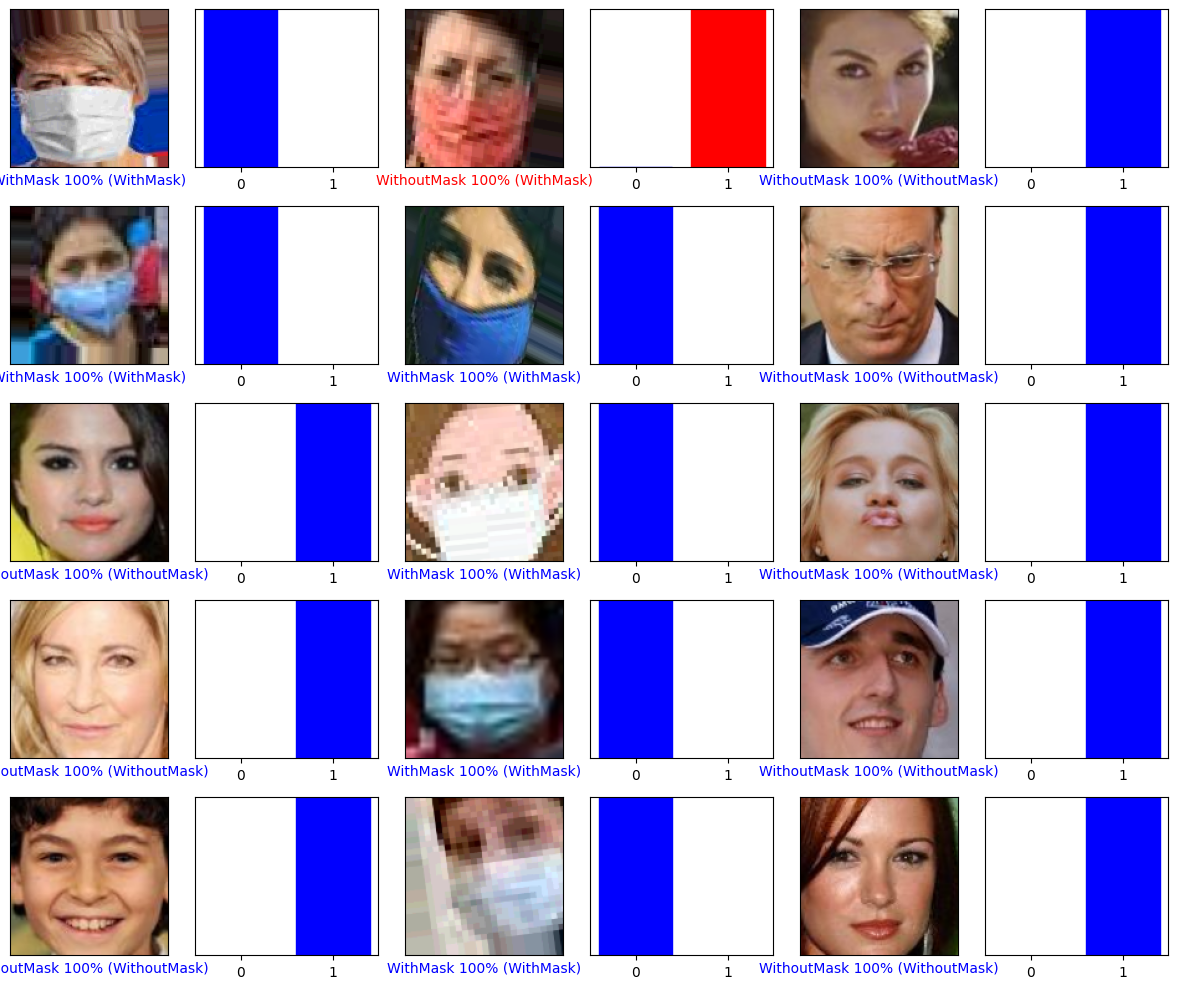

In [3]:
from train.evaluate import main

model, loss, accuracy = main("face-mask-12k-images-dataset/Face Mask Dataset", "checkpoints/baseline_cnn")

I0000 00:00:1776089139.400562  110845 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776089139.432927  110845 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776089140.473892  110845 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.


W0000 00:00:1776089141.977215  110845 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776089141.993922  110845 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776089142.100924  110845 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94891 MB memory:  -> device: 0, name: NVIDIA RTX PRO 6000 Blackwell Server Edition, pci bus id: 0000:76:00.0, compute capability: 12.0a


Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
Finding latest checkpoint...
Loading model from: checkpoints/baseline_cnn/model-20-0.0096.h5


Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


I0000 00:00:1776089144.777466  111889 service.cc:153] XLA service 0x702d1802df30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776089144.777519  111889 service.cc:161]   StreamExecutor [0]: NVIDIA RTX PRO 6000 Blackwell Server Edition, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776089144.789779  111889 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776089144.834444  111889 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776089144.986328  114044 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776089145.152567  114042 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 76 bytes spill stores, 7

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


I0000 00:00:1776089146.154029  111889 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

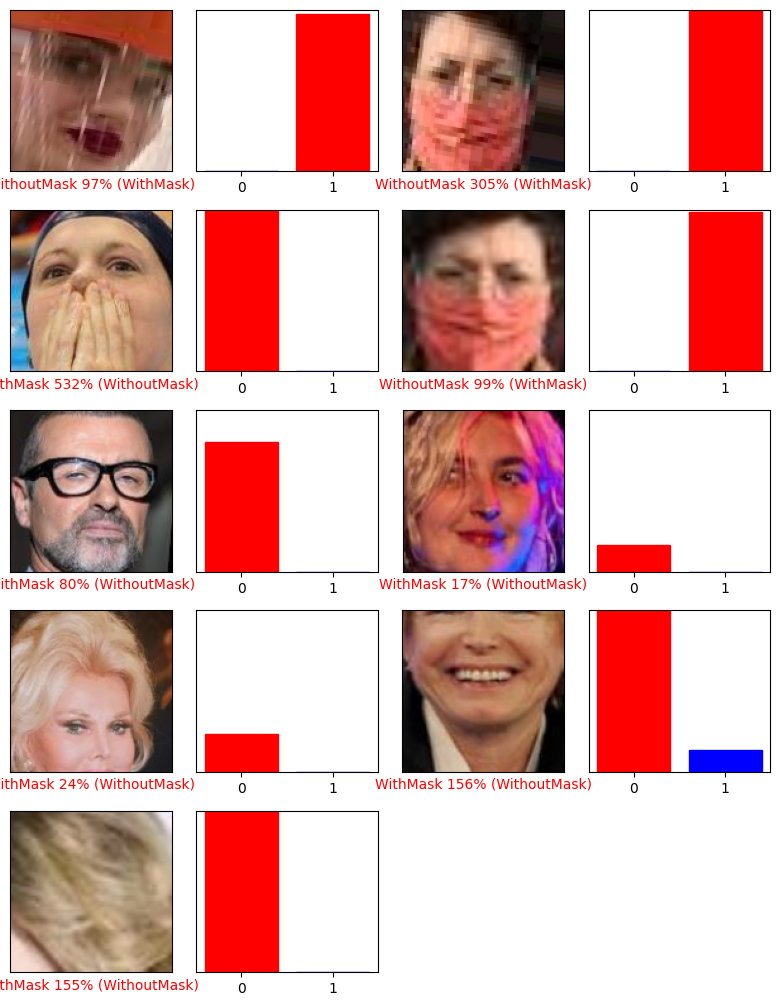

In [1]:
from train.evaluate import error_analysis
error_analysis()

## Observations for incorrectly labeled¶
- Faces having red/pink/similar to skin color mask often get mistaken as having no mask.
- transparent mask often identified as no mask
- hand covering face

## No overfitting, perhaps some bias
- accuracy: 0.9933 - loss: 0.0195 - val_accuracy: 0.9950 - val_loss: 0.0096
- Test Loss: 0.0348, Test Accuracy: 0.9909,
- can try transfer learning
- try more complex model

## if possible, get more data in priority
- more data of transparent mask
- more data of skin colored mask

### 64 filter baseline model
```
model = tf.keras.Sequential(
        [
            tf.keras.layers.Rescaling(1.0 / 255),
            tf.keras.layers.Conv2D(64, 3, activation="relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(64, 3, activation="relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(64, 3, activation="relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.Dense(num_classes),
        ]
    )
```

In [2]:
!python -m train baseline_cnn_64 

I0000 00:00:1776089549.771662  130155 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776089549.803081  130155 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776089550.803813  130155 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Loading model: baseline_cnn_64
Loading datasets...
Found 10000 files belonging to 2 classes.
W0000 00:

Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


Finding latest checkpoint...
Loading model from: checkpoints/baseline_cnn_64/model-20-0.0060.h5

Evaluating model...
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9929 - loss: 0.0398  
Test Loss: 0.0398
Test Accuracy: 0.9929
['WithMask', 'WithoutMask']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step


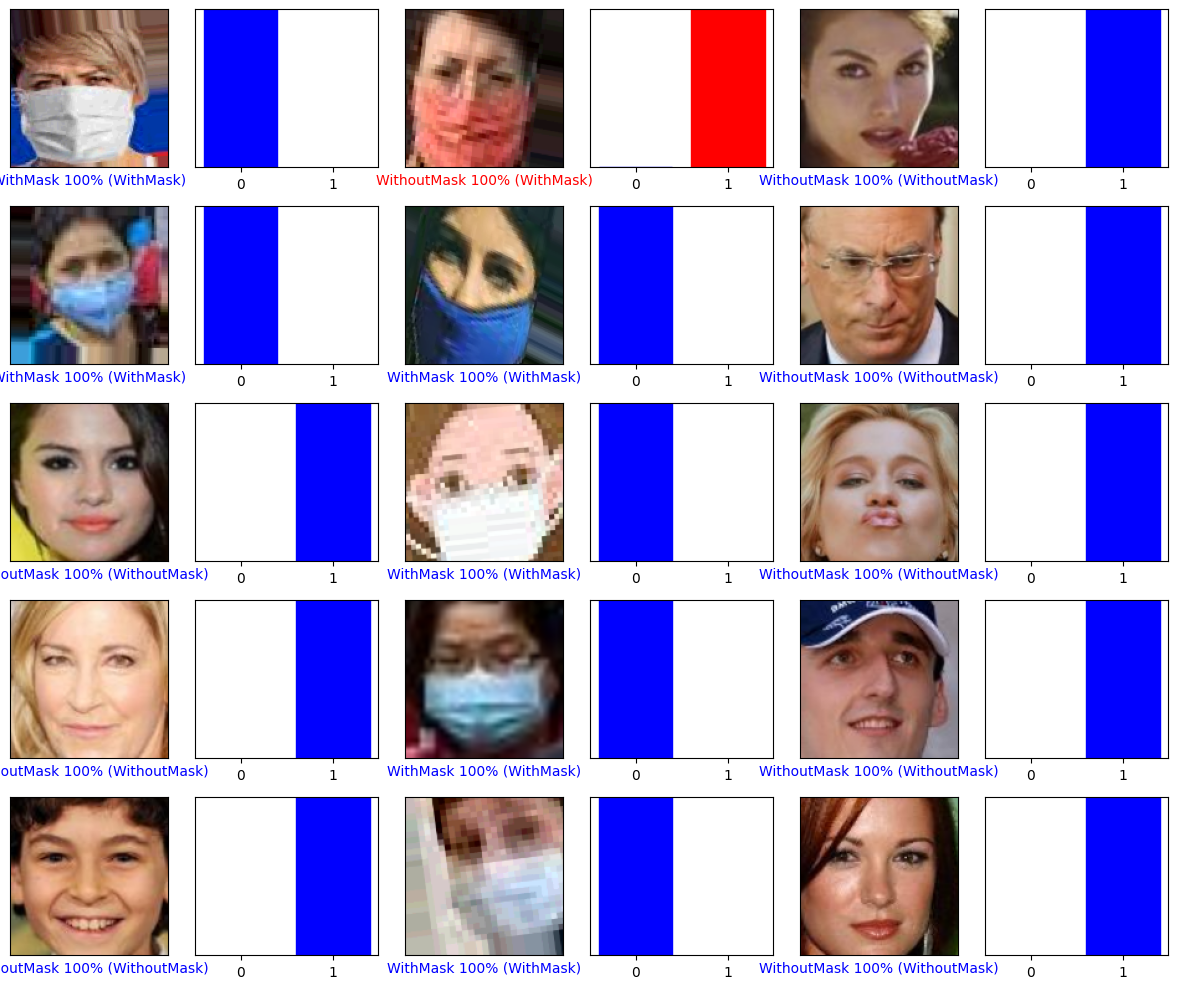

In [4]:
from train.evaluate import main

model, loss, accuracy = main("face-mask-12k-images-dataset/Face Mask Dataset", "checkpoints/baseline_cnn_64")

I0000 00:00:1776089921.201695  178636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776089921.232735  178636 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776089922.248997  178636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.


W0000 00:00:1776089923.887737  178636 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776089923.905264  178636 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776089924.014688  178636 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94891 MB memory:  -> device: 0, name: NVIDIA RTX PRO 6000 Blackwell Server Edition, pci bus id: 0000:76:00.0, compute capability: 12.0a


Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
Finding latest checkpoint...
Loading model from: checkpoints/baseline_cnn_64/model-20-0.0060.h5


Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


I0000 00:00:1776089926.549850  179677 service.cc:153] XLA service 0x7c7b1402d990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776089926.549894  179677 service.cc:161]   StreamExecutor [0]: NVIDIA RTX PRO 6000 Blackwell Server Edition, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776089926.561747  179677 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776089926.612040  179677 cuda_dnn.cc:461] Loaded cuDNN version 92000


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

I0000 00:00:1776089927.890784  179677 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━

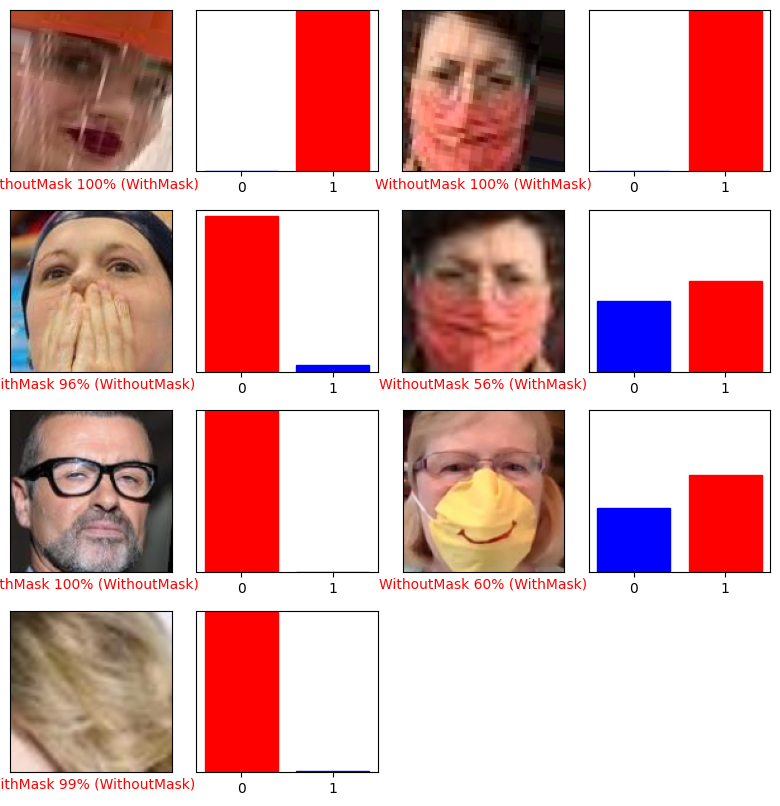

In [1]:
from train.evaluate import error_analysis
error_analysis(checkpoint_dir="checkpoints/baseline_cnn_64")

### Analysis of 64 filter model
- Test Loss: 0.0398
- Test Accuracy: 0.9929
- accuracy: 1.0000 - loss: 1.6819e-05 - val_accuracy: 0.9987 - val_loss: 0.0062
- similar issues as baseline model

## Transfer Learning with inception

In [4]:
!python -m train transfer_inception 

I0000 00:00:1776091850.152082  258009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776091850.183519  258009 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1776091851.238985  258009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Loading model: transfer_inception
Loading datasets...
Found 10000 files belonging to 2 classes.
W0000 00:00:1776091852.720850  258009 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776091852.732999  258009 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776091852.833994  258009 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1017 MB memory:  -> device: 0, n

I0000 00:00:1776092194.943153  289889 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776092194.974783  289889 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776092196.005894  289889 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.


W0000 00:00:1776092197.691357  289889 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776092197.707468  289889 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776092197.804039  289889 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94891 MB memory:  -> device: 0, name: NVIDIA RTX PRO 6000 Blackwell Server Edition, pci bus id: 0000:76:00.0, compute capability: 12.0a


Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
Finding latest checkpoint...
Loading model from: checkpoints/transfer_inception/model-20-0.0135.keras

Evaluating model...


I0000 00:00:1776092200.869711  290928 service.cc:153] XLA service 0x7ab5c8057040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776092200.869771  290928 service.cc:161]   StreamExecutor [0]: NVIDIA RTX PRO 6000 Blackwell Server Edition, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776092200.935748  290928 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776092201.186404  290928 cuda_dnn.cc:461] Loaded cuDNN version 92000
E0000 00:00:1776092202.310877  290928 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776092203.192584  290928 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsigh

31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9940 - loss: 0.0166
Test Loss: 0.0166
Test Accuracy: 0.9940
['WithMask', 'WithoutMask']
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


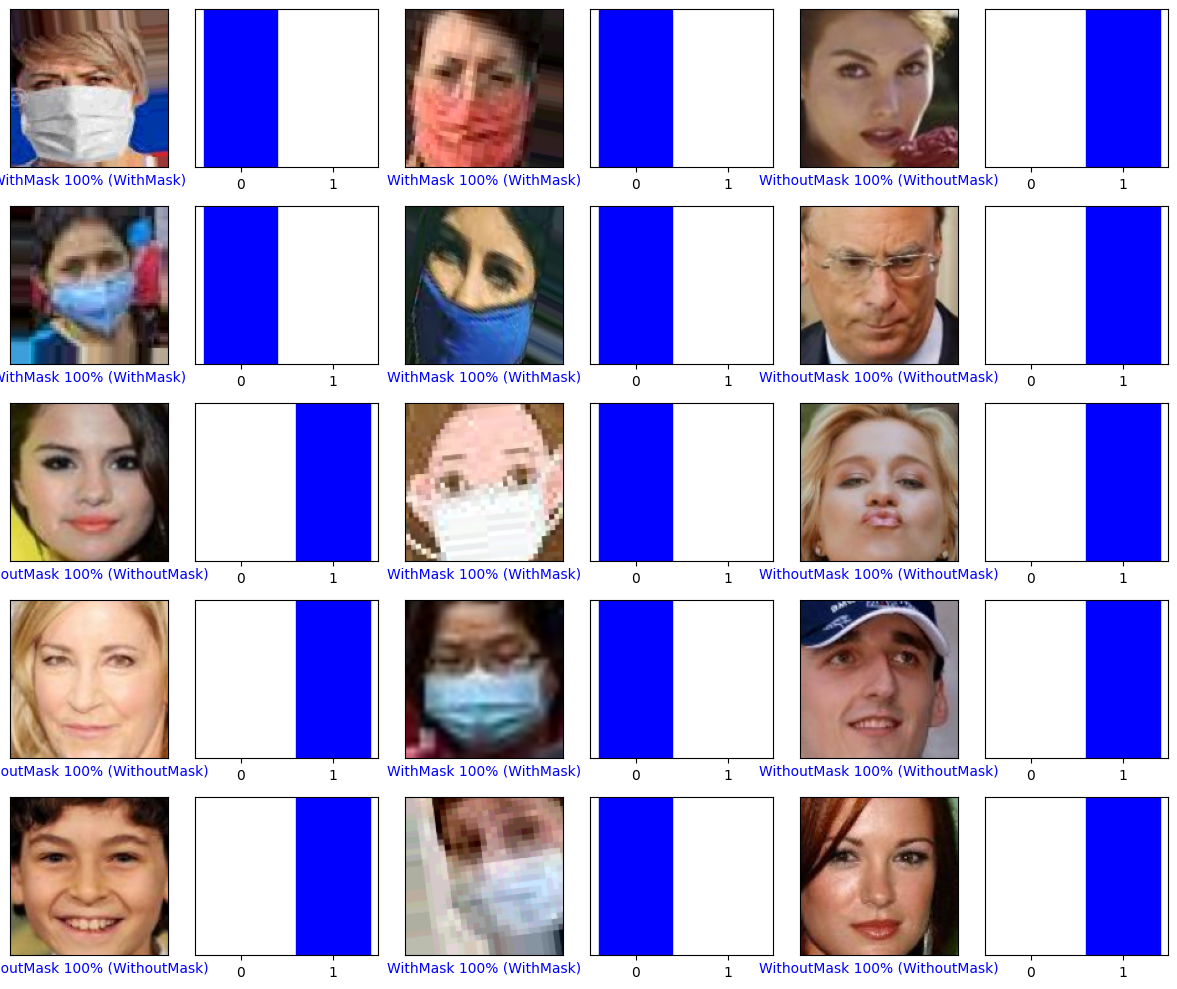

In [1]:
from train.evaluate import main

model, loss, accuracy = main("face-mask-12k-images-dataset/Face Mask Dataset", "checkpoints/transfer_inception")

Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
Finding latest checkpoint...
Loading model from: checkpoints/transfer_inception/model-20-0.0135.keras
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━

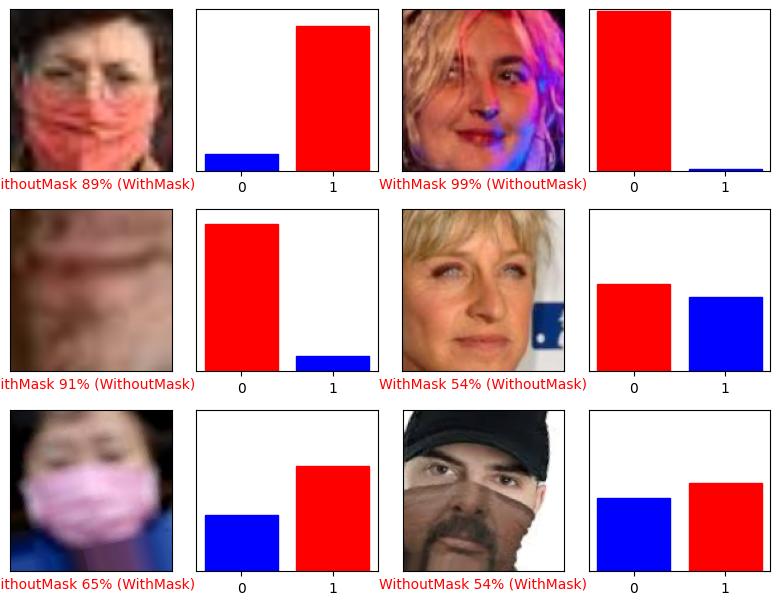

In [2]:
from train.evaluate import error_analysis
error_analysis(checkpoint_dir="checkpoints/transfer_inception")

### Observations for transfer learning with inception
- Test Loss: 0.0166, Test Accuracy: 0.9940
- accuracy: 0.9983 - loss: 0.0083 - val_accuracy: 0.9987 - val_loss: 0.0135
Evaluating model on test set...
- 4/9 incorrectly labeled as no mask because mask is pink/biege etc
- 1 each for cases: mask with face patterns, 

## Inception Transfer Learning (Unfrozen weights)
Let's allow training to also modify some of the pre-trained weights

In [1]:
!python -m train transfer_inception_unfrozen

I0000 00:00:1777184411.244979    5954 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading model: transfer_inception_unfrozen
Loading datasets...
Found 10000 files belonging to 2 classes.
I0000 00:00:1777184415.019013    5954 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22282 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
Classes: ['WithMask', 'WithoutMask']
Optimizing datasets...
Creating model...
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
You must install pydot (`pip install pydot`) for `plot_model` to work.
Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━

I0000 00:00:1777184669.025846    5938 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.


I0000 00:00:1777184672.133190    5938 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22282 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9


Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
Finding latest checkpoint...
Loading model from: checkpoints/transfer_inception_unfrozen/model-20-0.0032.keras

Evaluating model...


I0000 00:00:1777184676.751024   21731 service.cc:153] XLA service 0x76d6e8057700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777184676.751074   21731 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777184676.830461   21731 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777184677.119015   21731 cuda_dnn.cc:461] Loaded cuDNN version 92101
E0000 00:00:1777184680.128854   21731 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777184682.350824   21731 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:

31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9970 - loss: 0.0130
Test Loss: 0.0130
Test Accuracy: 0.9970
['WithMask', 'WithoutMask']
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


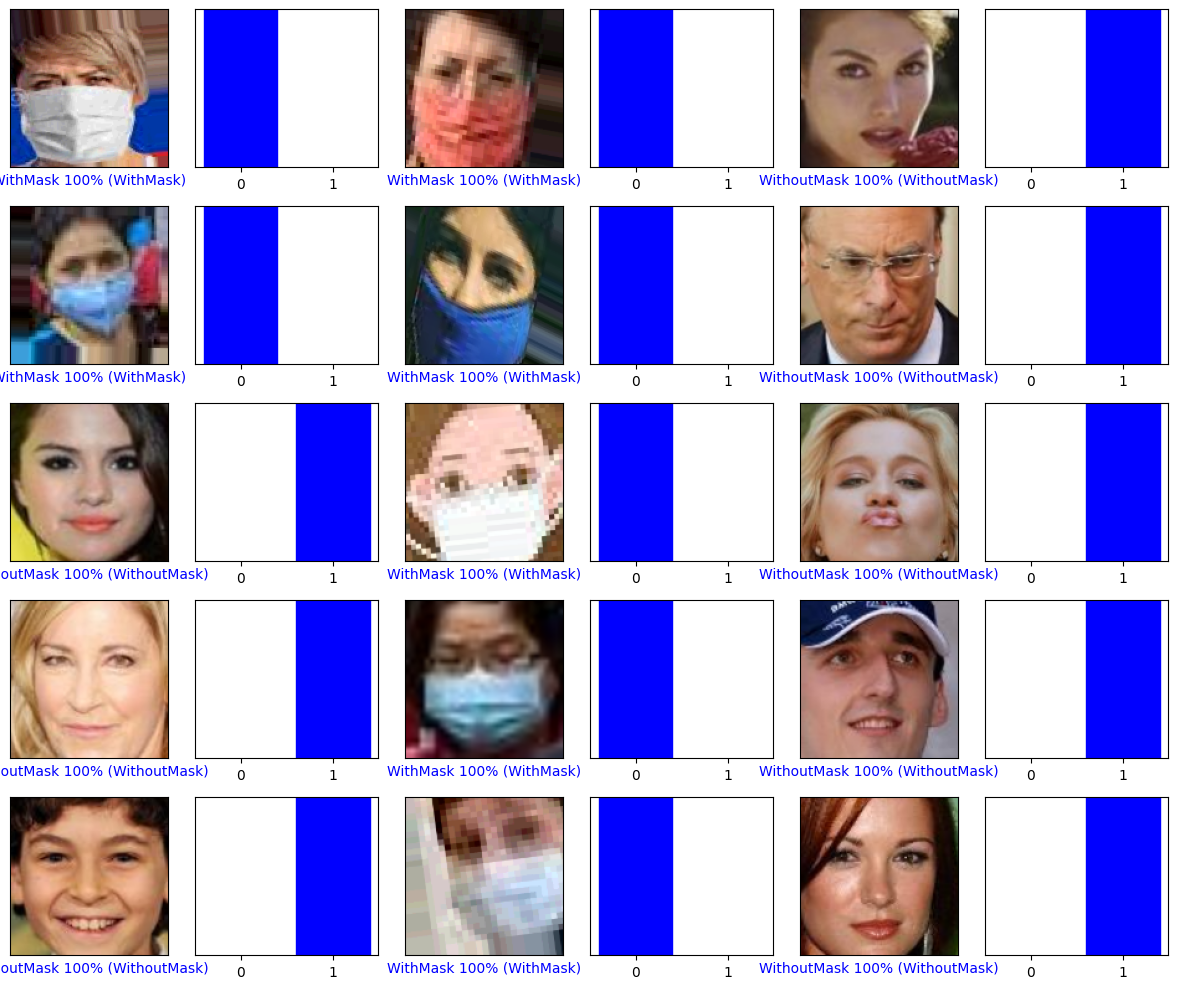

In [2]:
from train.evaluate import main

model, loss, accuracy = main("face-mask-12k-images-dataset/Face Mask Dataset", "checkpoints/transfer_inception_unfrozen")


Loading dataset from face-mask-12k-images-dataset/Face Mask Dataset...
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


Finding latest checkpoint...
Loading model from: checkpoints/transfer_inception_unfrozen/model-20-0.0032.keras
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━

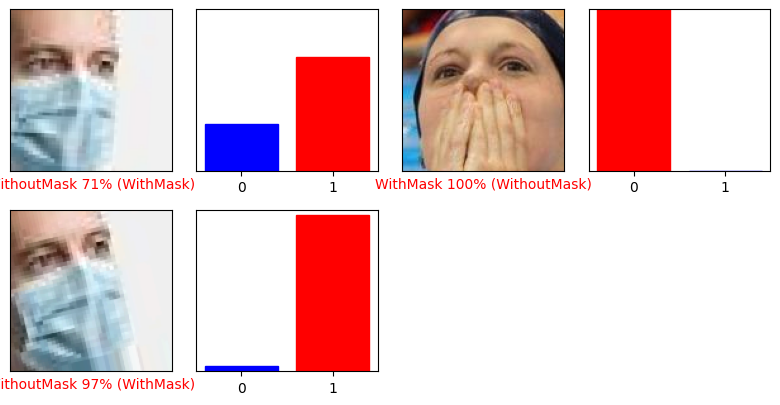

In [5]:
from train.evaluate import error_analysis
error_analysis(checkpoint_dir="checkpoints/transfer_inception_unfrozen")

### Error analysis
- Largely all errors are resolved 
- picture with hand covering face still predicting as having mask
- pictures with very light colored mask still predicting incorrectly as without mask


## Transfer Learning with Dino V2
Dino V2 is the current state of the arts for pre-trained wieghts

In [ ]:
!python -m train transfer_dino_v2

In [ ]:
from train.evaluate import main

model, loss, accuracy = main("face-mask-12k-images-dataset/Face Mask Dataset", "checkpoints/transfer_dino_v2")

In [ ]:
from train.evaluate import error_analysis
error_analysis(checkpoint_dir="checkpoints/transfer_dino_v2")

## RESULTS
| Model | Description | Train Accuracy | Val Accuracy | Test Accuracy | Notes |
|-|-|-|-|-|-|
| Baseline model |20 epochs, no transfer learning| 0.9933 | 0.9950 |  0.9909 | No overfitting, some edge cases |
| 64 filter baseline model |20 epochs, no transfer learning| 1.0000 | 0.9987 |  0.9929 | No overfitting, some edge cases, very slightly better than baseline |
| Transfer learning with (frozen) inception model |20 epochs| 0.9983 | 0.9987 | 0.9940 | slightly better accuracy, but edge cases largely remain |
| Transfer learning with (unfrozen) inception model |20 epochs| 1 | 0.9975 | 0.9970 | Largely all errors resolved, some edge cases |